In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, KFold
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error

In [2]:
data = pd.read_csv("../datasets/real_estate_properties_data_cleaned.csv")

In [3]:
X = data.copy().drop(columns = "price")
y = data["price"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42
)

In [4]:
scaling_columns = [
    "num_bath",
    "num_bed",
    "num_parking",
    "property_size",
    "day",
    "month",
    "year"
]

In [5]:
scaler = MinMaxScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[scaling_columns] = scaler.fit_transform(
    X_train[scaling_columns]
)

X_test_scaled[scaling_columns] = scaler.transform(
    X_test[scaling_columns]
)

In [6]:
base_model = LinearRegression()

base_model.fit(X_train_scaled, y_train)

train_predictions = base_model.predict(X_train_scaled)
test_predictions = base_model.predict(X_test_scaled)

In [7]:
train_mse = mean_squared_error(y_train, train_predictions)
test_mse = mean_squared_error(y_test, test_predictions)
train_mae = mean_absolute_error(y_train, train_predictions)
test_mae = mean_absolute_error(y_test, test_predictions)
train_rmse = root_mean_squared_error(y_train, train_predictions)
test_rmse = root_mean_squared_error(y_test, test_predictions)
train_r2 = r2_score(y_train, train_predictions)
test_r2 = r2_score(y_test, test_predictions)

In [8]:
base_results = pd.DataFrame({
    "Metric": [
        "MSE",
        "MAE",
        "RMSE",
        "R2"
    ],
    "Training": [
        train_mse,
        train_mae,
        train_rmse,
        train_r2
    ],
    "Testing": [
        test_mse,
        test_mae,
        test_rmse,
        test_r2
    ]
})

bmelt_results = base_results.melt(
    id_vars = "Metric",
    var_name = "Dataset",
    value_name = "Score"
)

print(base_results)

  Metric      Training       Testing
0    MSE  3.520880e+12  2.954811e+12
1    MAE  1.157390e+06  1.257416e+06
2   RMSE  1.876401e+06  1.718956e+06
3     R2  7.215000e-01  7.014899e-01


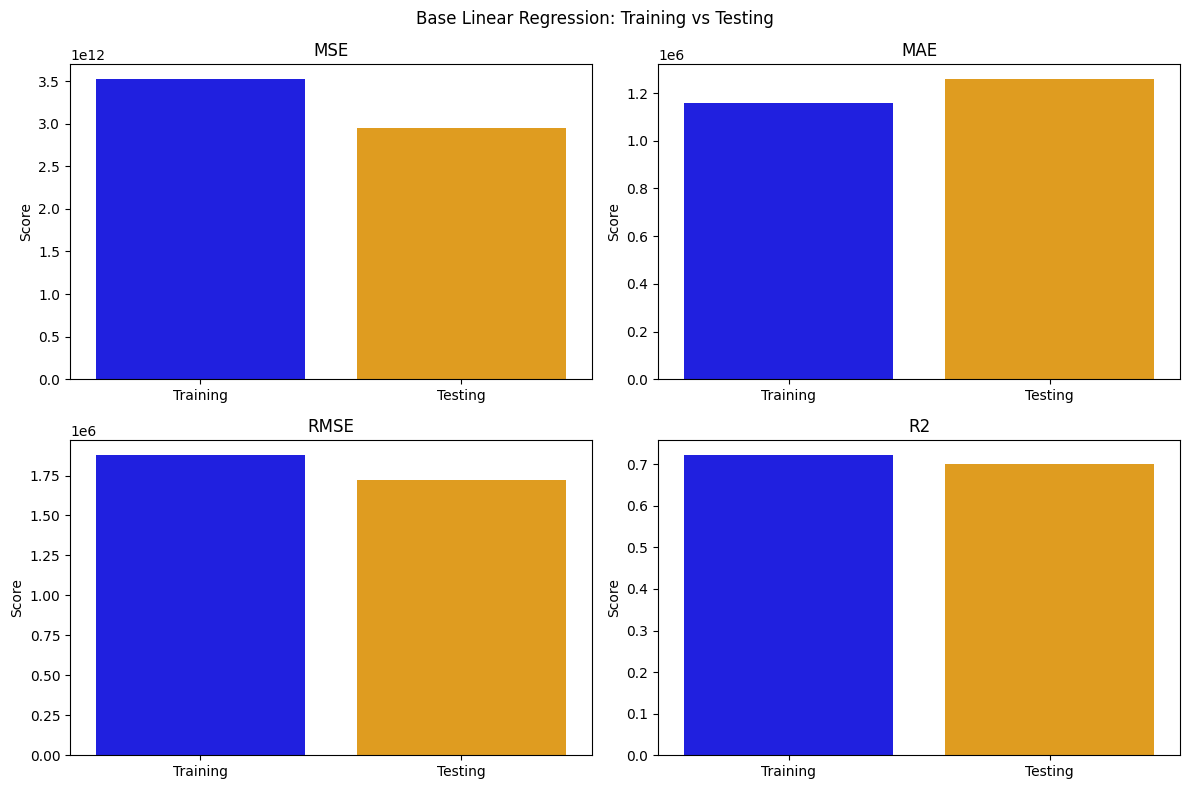

In [9]:
fig, axes = plt.subplots(2, 2, figsize = (12, 8))

for ax, metric in zip(axes.flat, base_results["Metric"]):
    metric_data = bmelt_results[bmelt_results["Metric"] == metric]

    sns.barplot(
        data = metric_data,
        x = "Dataset",
        y = "Score",
        hue = "Dataset",
        palette = {"Training": "blue", "Testing": "orange"},
        ax = ax
    )

    ax.set_title(metric)
    ax.set_xlabel("")
    ax.set_ylabel("Score")

fig.suptitle("Base Linear Regression: Training vs Testing")
plt.tight_layout()
plt.show()

In [10]:
alpha = [0.01, 0.1, 1, 10, 100]
l1_ratio = [0.1, 0.3, 0.5, 0.7, 0.9]

parameter_combinations = []

for a in alpha:
    for ratio in l1_ratio:
        parameter_combinations.append({
            "alpha": a,
            "l1_ratio": ratio
        })

lasso_params = []

for a in alpha:
    lasso_params.append({
        "alpha": a
    })

ridge_params = []

for a in alpha:
    ridge_params.append({
        "alpha": a
    })

In [11]:
kf = KFold(
    n_splits = 5,
    shuffle = True,
    random_state = 42
)

In [12]:
def cross_validation(model : str, hyperparameters : list, cv : KFold, Xtraining: pd.DataFrame, ytraining: np.array) -> list:
    fold_results = []

    for param in hyperparameters:
        mae_results = []
        rmse_results = []
        r2_results = []
        for fold, (train_index, validation_index) in enumerate(cv.split(Xtraining)):

            X_fold_train = Xtraining.iloc[train_index]
            X_fold_validation = Xtraining.iloc[validation_index]

            y_fold_train = ytraining.iloc[train_index]
            y_fold_validation = ytraining.iloc[validation_index]

            if model == "lasso":
                fold_model = Lasso(
                    **param,
                    max_iter = 50000000
                )
            elif model == "ridge":
                fold_model = Ridge(
                    **param
                )
            elif model == "elastic":
                fold_model = ElasticNet(
                    **param,
                    max_iter = 50000000
                )
            else:
                print(f"Do not support model {model} !")
                break

            fold_model.fit(X_fold_train, y_fold_train)

            validation_predictions = fold_model.predict(X_fold_validation)

            mae = mean_absolute_error(y_fold_validation, validation_predictions)
            mae_results.append(mae)

            rmse = root_mean_squared_error(y_fold_validation, validation_predictions)
            rmse_results.append(rmse)

            r2 = r2_score(y_fold_validation, validation_predictions)
            r2_results.append(r2)

        fold_results.append({
            "MAE": np.array(mae_results).mean(),
            "RMSE": np.array(rmse_results).mean(),
            "R2": np.array(r2_results).mean()
        })

    return fold_results

In [13]:
lasso_fold = cross_validation("lasso", lasso_params, kf, X_train_scaled, y_train)
ridge_fold = cross_validation("ridge", ridge_params, kf, X_train_scaled, y_train)
elastic_fold = cross_validation("elastic", parameter_combinations, kf, X_train_scaled, y_train)

In [14]:
lasso_fold = pd.DataFrame(lasso_fold)
print(lasso_fold)

            MAE          RMSE        R2
0  1.489734e+06  2.375199e+06 -1.608162
1  1.489733e+06  2.375199e+06 -1.608160
2  1.489722e+06  2.375195e+06 -1.608147
3  1.489611e+06  2.375159e+06 -1.608015
4  1.488503e+06  2.374793e+06 -1.606689


In [15]:
lasso_model = Lasso(
    **lasso_params[4],
    max_iter = 50000000
)

lasso_model.fit(X_train_scaled, y_train)

lasso_train_predictions = lasso_model.predict(X_train_scaled)
lasso_test_predictions = lasso_model.predict(X_test_scaled)

In [16]:
lasso_train_mse = mean_squared_error(y_train, lasso_train_predictions)
lasso_test_mse = mean_squared_error(y_test, lasso_test_predictions)
lasso_train_mae = mean_absolute_error(y_train, lasso_train_predictions)
lasso_test_mae = mean_absolute_error(y_test, lasso_test_predictions)
lasso_train_rmse = root_mean_squared_error(y_train, lasso_train_predictions)
lasso_test_rmse = root_mean_squared_error(y_test, lasso_test_predictions)
lasso_train_r2 = r2_score(y_train, lasso_train_predictions)
lasso_test_r2 = r2_score(y_test, lasso_test_predictions)

In [17]:
lasso_results = pd.DataFrame({
    "Metric": [
        "MSE",
        "MAE",
        "RMSE",
        "R2"
    ],
    "Training": [
        lasso_train_mse,
        lasso_train_mae,
        lasso_train_rmse,
        lasso_train_r2
    ],
    "Testing": [
        lasso_test_mse,
        lasso_test_mae,
        lasso_test_rmse,
        lasso_test_r2
    ]
})

lmelt_results = lasso_results.melt(
    id_vars = "Metric",
    var_name = "Dataset",
    value_name = "Score"
)

print(lasso_results)

  Metric      Training       Testing
0    MSE  3.520891e+12  2.954137e+12
1    MAE  1.156663e+06  1.257105e+06
2   RMSE  1.876404e+06  1.718760e+06
3     R2  7.214992e-01  7.015580e-01


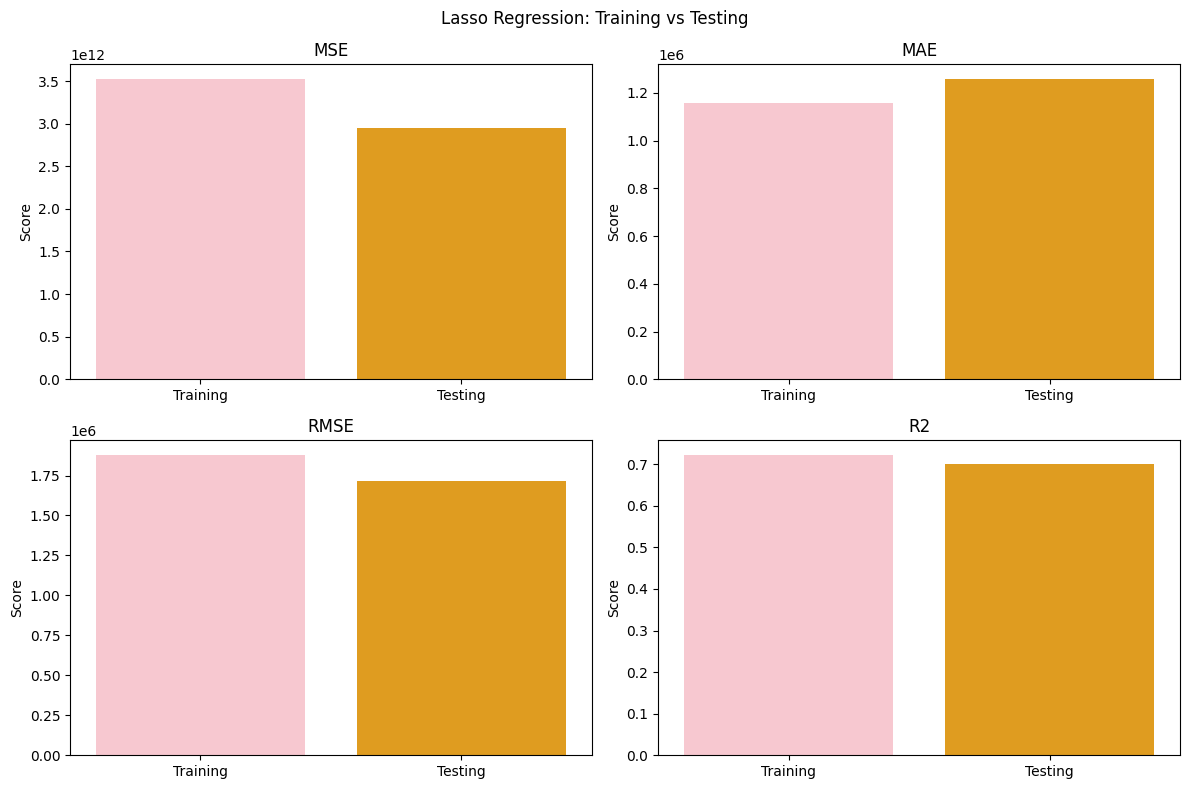

In [18]:
fig, axes = plt.subplots(2, 2, figsize = (12, 8))

for ax, metric in zip(axes.flat, lasso_results["Metric"]):
    metric_data = lmelt_results[lmelt_results["Metric"] == metric]

    sns.barplot(
        data = metric_data,
        x = "Dataset",
        y = "Score",
        hue = "Dataset",
        palette = {"Training": "pink", "Testing": "orange"},
        ax = ax
    )

    ax.set_title(metric)
    ax.set_xlabel("")
    ax.set_ylabel("Score")

fig.suptitle("Lasso Regression: Training vs Testing")
plt.tight_layout()
plt.show()

In [19]:
ridge_fold = pd.DataFrame(ridge_fold)
print(ridge_fold)

            MAE          RMSE        R2
0  1.470635e+06  2.347344e+06 -1.427882
1  1.400118e+06  2.301901e+06 -1.190417
2  1.244403e+06  2.220137e+06 -0.408146
3  1.232977e+06  2.274868e+06  0.261805
4  1.649930e+06  2.858069e+06 -0.027300


In [20]:
ridge_model = Ridge(
    **ridge_params[3],
    max_iter = 50000000
)

ridge_model.fit(X_train_scaled, y_train)

ridge_train_predictions = ridge_model.predict(X_train_scaled)
ridge_test_predictions = ridge_model.predict(X_test_scaled)

In [21]:
ridge_train_mse = mean_squared_error(y_train, ridge_train_predictions)
ridge_test_mse = mean_squared_error(y_test, ridge_test_predictions)
ridge_train_mae = mean_absolute_error(y_train, ridge_train_predictions)
ridge_test_mae = mean_absolute_error(y_test, ridge_test_predictions)
ridge_train_rmse = root_mean_squared_error(y_train, ridge_train_predictions)
ridge_test_rmse = root_mean_squared_error(y_test, ridge_test_predictions)
ridge_train_r2 = r2_score(y_train, ridge_train_predictions)
ridge_test_r2 = r2_score(y_test, ridge_test_predictions)

In [22]:
ridge_results = pd.DataFrame({
    "Metric": [
        "MSE",
        "MAE",
        "RMSE",
        "R2"
    ],
    "Training": [
        ridge_train_mse,
        ridge_train_mae,
        ridge_train_rmse,
        ridge_train_r2
    ],
    "Testing": [
        ridge_test_mse,
        ridge_test_mae,
        ridge_test_rmse,
        ridge_test_r2
    ]
})

rmelt_results = ridge_results.melt(
    id_vars = "Metric",
    var_name = "Dataset",
    value_name = "Score"
)

print(ridge_results)

  Metric      Training       Testing
0    MSE  5.684489e+12  3.920812e+12
1    MAE  1.147767e+06  1.090366e+06
2   RMSE  2.384217e+06  1.980104e+06
3     R2  5.503595e-01  6.038996e-01


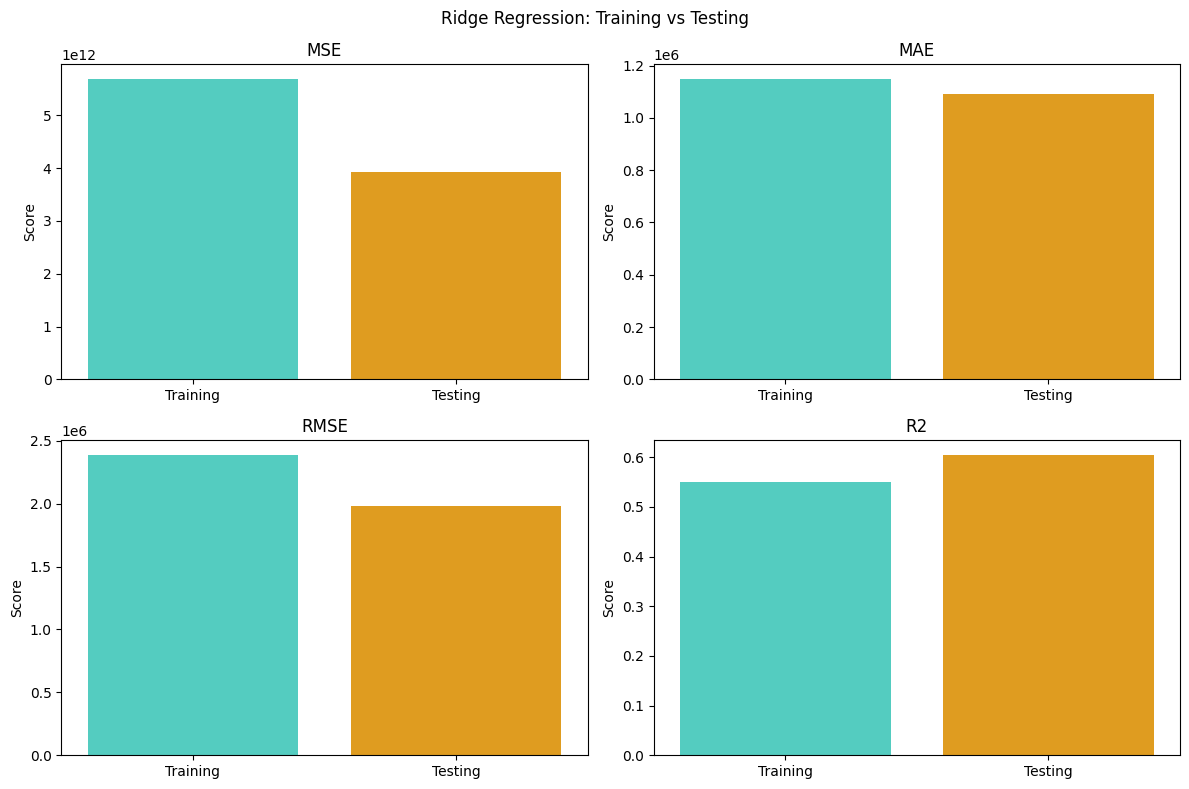

In [23]:
fig, axes = plt.subplots(2, 2, figsize = (12, 8))

for ax, metric in zip(axes.flat, ridge_results["Metric"]):
    metric_data = rmelt_results[rmelt_results["Metric"] == metric]

    sns.barplot(
        data = metric_data,
        x = "Dataset",
        y = "Score",
        hue = "Dataset",
        palette = {"Training": "turquoise", "Testing": "orange"},
        ax = ax
    )

    ax.set_title(metric)
    ax.set_xlabel("")
    ax.set_ylabel("Score")

fig.suptitle("Ridge Regression: Training vs Testing")
plt.tight_layout()
plt.show()

In [24]:
elastic_fold = pd.DataFrame(elastic_fold)
print(elastic_fold)

             MAE          RMSE        R2
0   1.263360e+06  2.226126e+06 -0.535505
1   1.280088e+06  2.232643e+06 -0.627473
2   1.307344e+06  2.244273e+06 -0.754549
3   1.345727e+06  2.266121e+06 -0.943545
4   1.414119e+06  2.311169e+06 -1.245393
5   1.247323e+06  2.246658e+06  0.181321
6   1.252962e+06  2.234422e+06  0.115351
7   1.256913e+06  2.224761e+06  0.017779
8   1.257462e+06  2.218621e+06 -0.139462
9   1.256814e+06  2.223990e+06 -0.498071
10  1.553934e+06  2.746384e+06  0.087261
11  1.481259e+06  2.665677e+06  0.160322
12  1.387856e+06  2.558708e+06  0.242709
13  1.267584e+06  2.417011e+06  0.313745
14  1.244096e+06  2.253494e+06  0.206401
15  1.911346e+06  3.183764e+06 -0.441101
16  1.895732e+06  3.163273e+06 -0.411508
17  1.868469e+06  3.127899e+06 -0.361553
18  1.808800e+06  3.052229e+06 -0.259465
19  1.583033e+06  2.779422e+06  0.054996
20  1.962884e+06  3.252585e+06 -0.544036
21  1.961191e+06  3.250295e+06 -0.540523
22  1.958152e+06  3.246191e+06 -0.534241
23  1.951111e+06

In [25]:
elastic_model = ElasticNet(
    **parameter_combinations[13],
    max_iter = 50000000
)

elastic_model.fit(X_train_scaled, y_train)

elastic_train_predictions = elastic_model.predict(X_train_scaled)
elastic_test_predictions = elastic_model.predict(X_test_scaled)

In [26]:
elastic_train_mse = mean_squared_error(y_train, elastic_train_predictions)
elastic_test_mse = mean_squared_error(y_test, elastic_test_predictions)
elastic_train_mae = mean_absolute_error(y_train, elastic_train_predictions)
elastic_test_mae = mean_absolute_error(y_test, elastic_test_predictions)
elastic_train_rmse = root_mean_squared_error(y_train, elastic_train_predictions)
elastic_test_rmse = root_mean_squared_error(y_test, elastic_test_predictions)
elastic_train_r2 = r2_score(y_train, elastic_train_predictions)
elastic_test_r2 = r2_score(y_test, elastic_test_predictions)

In [27]:
elastic_results = pd.DataFrame({
    "Metric": [
        "MSE",
        "MAE",
        "RMSE",
        "R2"
    ],
    "Training": [
        elastic_train_mse,
        elastic_train_mae,
        elastic_train_rmse,
        elastic_train_r2
    ],
    "Testing": [
        elastic_test_mse,
        elastic_test_mae,
        elastic_test_rmse,
        elastic_test_r2
    ]
})

emelt_results = elastic_results.melt(
    id_vars = "Metric",
    var_name = "Dataset",
    value_name = "Score"
)

print(elastic_results)

  Metric      Training       Testing
0    MSE  7.197007e+12  5.016152e+12
1    MAE  1.198483e+06  1.055133e+06
2   RMSE  2.682724e+06  2.239677e+06
3     R2  4.307201e-01  4.932428e-01


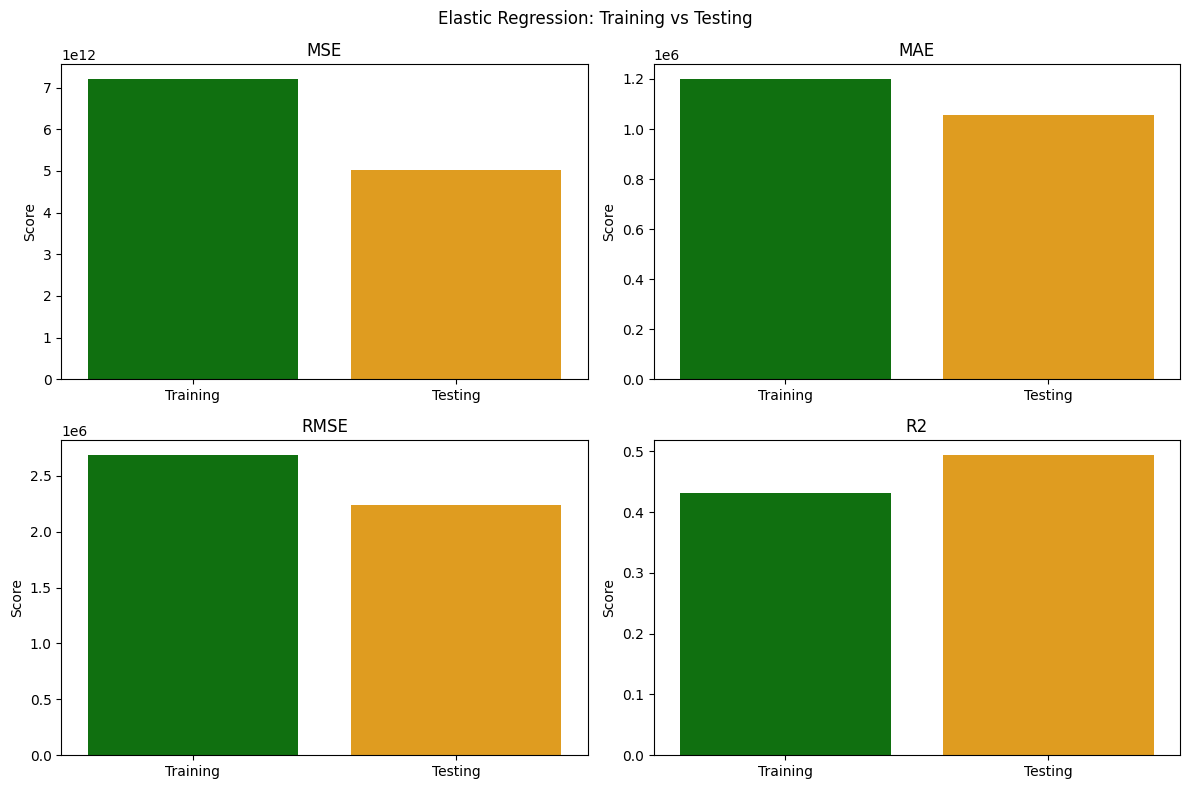

In [28]:
fig, axes = plt.subplots(2, 2, figsize = (12, 8))

for ax, metric in zip(axes.flat, elastic_results["Metric"]):
    metric_data = emelt_results[emelt_results["Metric"] == metric]

    sns.barplot(
        data = metric_data,
        x = "Dataset",
        y = "Score",
        hue = "Dataset",
        palette = {"Training": "green", "Testing": "orange"},
        ax = ax
    )

    ax.set_title(metric)
    ax.set_xlabel("")
    ax.set_ylabel("Score")

fig.suptitle("Elastic Regression: Training vs Testing")
plt.tight_layout()
plt.show()

In [29]:
model_package = {
    "model": lasso_model,
    "hyperparameters": lasso_params[4],
    "results": lasso_results
}

joblib.dump(model_package, filename = "../trained_model/linear_reg_model.joblib")

['../trained_model/linear_reg_model.joblib']